<h1>Support Vector Classifier (SVC)</h1>
<h2>1.Load Training, Validation, and Test Data</h2>

In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Load dataset
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')

y_train = pd.read_csv('y_train.csv').values.ravel()
y_val = pd.read_csv('y_val.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (2117, 5), Validation: (530, 5), Test: (662, 5)


<h2>2.Handle Missing Values and Create New Features</h2>

In [2]:
for df in [X_train, X_val, X_test]:
    df.fillna(df.median(), inplace=True)
    df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    df['Hour_Day'] = df['Hour'] * df['DayOfWeek']
    df['Hour_squared'] = df['Hour'] ** 2
    df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)


<h2>3.Feature Scaling (Standardization)</h2>


In [3]:
numeric_cols = ['Hour', 'DayOfWeek']
X_train[numeric_cols] = X_train[numeric_cols].astype(float)
X_val[numeric_cols] = X_val[numeric_cols].astype(float)
X_test[numeric_cols] = X_test[numeric_cols].astype(float)

scaler = StandardScaler()
X_train.loc[:, numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val.loc[:, numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test.loc[:, numeric_cols] = scaler.transform(X_test[numeric_cols])


<h2>4.Define Hyperparameter Grid</h2>


In [4]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],               
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  
    'kernel': ['rbf']                           
}


<h2>5.Cross-Validation Setup</h2>


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

<h2>6.Grid Search with Cross-Validation</h2>


In [6]:
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

print("\nBest Params:", grid_search.best_params_)
print(f"Best CV Macro F1: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV Macro F1: 0.6302


<h2>7.Final Model Training (Train + Validation Combined)</h2>


In [7]:
X_final = pd.concat([X_train, X_val], axis=0)
y_final = np.concatenate([y_train, y_val])
best_model = grid_search.best_estimator_
best_model.fit(X_final, y_final)


SVC(C=10, gamma=0.001, probability=True, random_state=42)

<h2>8.Validation Set Performance</h2>


In [8]:
y_val_pred = best_model.predict(X_val)
print("\nValidation Set Performance:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Macro F1:", f1_score(y_val, y_val_pred, average='macro'))


Validation Set Performance:
Accuracy: 0.720754716981132
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.90      0.82       366
           1       0.59      0.32      0.42       164

    accuracy                           0.72       530
   macro avg       0.67      0.61      0.62       530
weighted avg       0.70      0.72      0.69       530

Confusion Matrix:
 [[329  37]
 [111  53]]
Macro F1: 0.6168500029307751


<h2>9.Test Set Performance</h2>


In [9]:
y_test_pred = best_model.predict(X_test)
print("\nTest Set Performance:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Macro F1:", f1_score(y_test, y_test_pred, average='macro'))


Test Set Performance:
Accuracy: 0.7205438066465257
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.89      0.81       457
           1       0.58      0.34      0.43       205

    accuracy                           0.72       662
   macro avg       0.67      0.62      0.62       662
weighted avg       0.70      0.72      0.70       662

Confusion Matrix:
 [[407  50]
 [135  70]]
Macro F1: 0.6227920227920227


<h2>9.Confusion Matrix</h2>


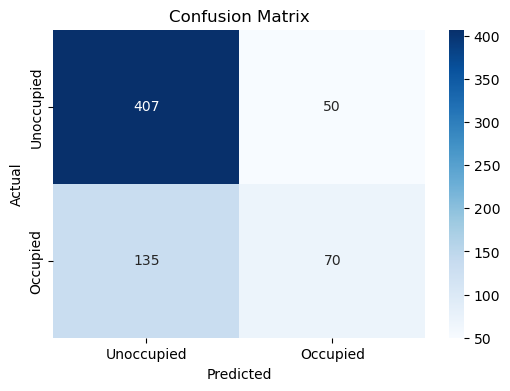

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Unoccupied', 'Occupied'], yticklabels=['Unoccupied', 'Occupied'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


<h2>10.Test Set - ROC Curve</h2>


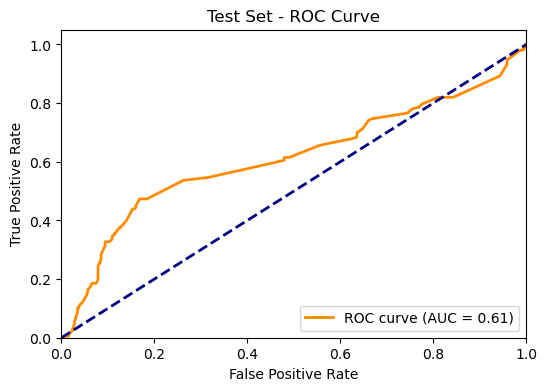

In [11]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_test_proba = best_model.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Set - ROC Curve')
plt.legend(loc="lower right")
plt.show()
